# Notebook 05 — ipywidgets

**What you will learn:**
- The observer pattern: widgets emit events, callbacks respond
- The difference between `interact()` and `interactive()`
- How to link widget state to xarray slice selection + matplotlib plots
- Why axes must be cleared before redrawing

---

## Background: The Observer Pattern

ipywidgets implements the **observer pattern**: each widget holds a value and fires a `change` event when that value changes. You register a callback (an `observe` handler or an `interactive` wrapper) that runs every time the value changes.

```
User changes widget → widget fires 'change' event → callback runs → plot updates
```

`interact()` creates widgets automatically from function arguments and displays everything inline.  
`interactive()` does the same but returns the widget object so you can compose it into a custom layout.

In [1]:
import sys
sys.path.insert(0, "..")

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display

ZARR_ENRICHED = "../data/sentinel2_enriched.zarr"
ds = xr.open_zarr(ZARR_ENRICHED)

print("Variables:", list(ds.data_vars))
print("Time steps:")
for t in ds.time.values:
    print(" ", str(t)[:10])

Variables: ['blue', 'green', 'ndvi', 'nir', 'red', 'spatial_ref']
Time steps:
  2023-06-04
  2023-08-13


## Create the widgets

We need:
- A **Dropdown** for band selection
- A **SelectionSlider** that steps through available dates

In [2]:
BANDS = ["blue", "green", "red", "nir", "ndvi"]
DATES = [str(t)[:10] for t in ds.time.values]  # list of 'YYYY-MM-DD' strings

band_widget = w.Dropdown(
    options=BANDS,
    value="ndvi",
    description="Band:",
    style={"description_width": "initial"},
)

date_widget = w.SelectionSlider(
    options=DATES,
    value=DATES[0],
    description="Date:",
    style={"description_width": "initial"},
    layout=w.Layout(width="500px"),
)

print("band_widget type:", type(band_widget).__name__)
print("date_widget type:", type(date_widget).__name__)

band_widget type: Dropdown
date_widget type: SelectionSlider


## Define the update function

The update function is called every time either widget changes. It must:
1. Select the right data slice from xarray
2. Choose an appropriate colormap
3. **Clear the axes** before drawing — otherwise each call draws on top of the previous one
4. Redraw and refresh the figure

In [3]:
CMAPS = {
    "blue":  "Blues",
    "green": "Greens",
    "red":   "Reds",
    "nir":   "YlOrBr",
    "ndvi":  "RdYlGn",
}

VLIMS = {
    "blue":  (0, 3000),
    "green": (0, 3000),
    "red":   (0, 3000),
    "nir":   (0, 5000),
    "ndvi":  (-0.2, 0.8),
}

def update_plot(band: str, date: str):
    """Select a band/date slice from xarray and display it."""
    # Select by label (sel) using the date string
    # ds.time coords are numpy datetime64 — we use method='nearest' to tolerate
    # slight timestamp differences (time might include HH:MM:SS)
    scene = ds[band].sel(time=date, method="nearest")
    arr = scene.compute().values

    vmin, vmax = VLIMS[band]
    cmap = CMAPS[band]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")
    plt.colorbar(im, ax=ax, fraction=0.03, label=band)
    ax.set_title(f"{band.upper()} — {date}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Wire with interactive() and display

`interactive()` wraps `update_plot` and returns a widget. We compose it into a `VBox` so we control the layout.

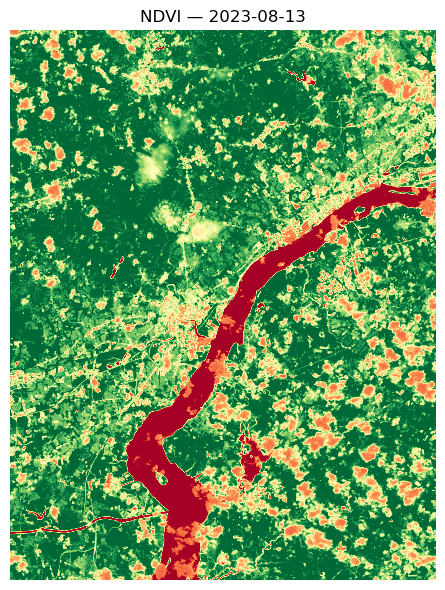

y: 4372290.0 to 4428030.0
x: 435510.0 to 478650.0


In [4]:
ds_check = xr.open_zarr("../data/sentinel2_enriched.zarr")

aug = ds_check.sel(time="2023-08-13", method="nearest")
arr = aug["ndvi"].compute().values

import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(arr, cmap="RdYlGn", vmin=-0.2, vmax=0.8, origin="upper")
ax.set_title("NDVI — 2023-08-13")
ax.axis("off")
plt.tight_layout()
plt.show()

print("y:", float(ds_check.y.min()), "to", float(ds_check.y.max()))
print("x:", float(ds_check.x.min()), "to", float(ds_check.x.max()))

In [5]:
from utils.stac_helpers import search_sentinel2
# searching for tile information
items = search_sentinel2()
for item in items:
    print(item.datetime.strftime("%Y-%m-%d"), "→", item.bbox)
    print("  tile:", item.properties.get("mgrs:utm_zone", item.properties.get("sentinel:utm_zone", "?")))
items_relaxed = search_sentinel2(max_cloud=50, max_items=20)
aug_items = [i for i in items_relaxed if "2023-08-13" in str(i.datetime)]
for item in aug_items:
    print(item.bbox, "cloud:", item.properties.get("eo:cloud_cover"))


2023-08-23 → [-76.18316062292897, 39.65576169772817, -74.88456877606482, 40.650789813976196]
  tile: 18
2023-08-13 → [-76.16761290616306, 38.755202928221415, -74.88608605736992, 39.7502030226425]
  tile: 18
2023-08-13 → [-76.18316062292897, 39.65576169772817, -74.88456877606482, 40.650789813976196]
  tile: 18
2023-08-03 → [-76.16761290616306, 38.755202928221415, -74.88608605736992, 39.7502030226425]
  tile: 18
2023-06-04 → [-76.16761290616306, 38.755202928221415, -74.88608605736992, 39.7502030226425]
  tile: 18
2023-06-04 → [-76.18316062292897, 39.65576169772817, -74.88456877606482, 40.650789813976196]
  tile: 18
[-76.16761290616306, 38.755202928221415, -74.88608605736992, 39.7502030226425] cloud: 12.651107
[-76.18316062292897, 39.65576169772817, -74.88456877606482, 40.650789813976196] cloud: 25.648847


In [6]:
ui = w.interactive(
    update_plot,
    band=band_widget,
    date=date_widget,
)

# ui.children[-1] is the output area; ui.children[:-1] are the widgets
controls = w.VBox(ui.children[:-1])
output = ui.children[-1]

display(w.VBox([controls, output]))

## Manual trigger test

Confirm the function runs without error when called directly (useful for non-interactive validation).

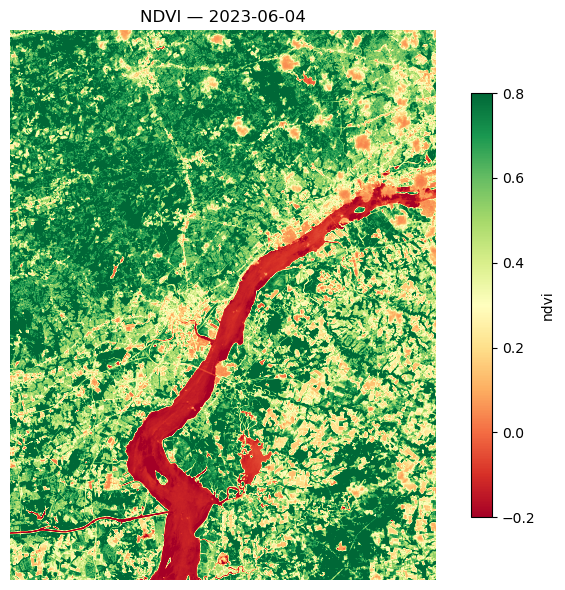

Manual trigger succeeded.


In [7]:
# This should display a plot without raising
update_plot("ndvi", DATES[0])
print("Manual trigger succeeded.")

## Validation

In [8]:
assert isinstance(band_widget, w.Dropdown), "band_widget should be a Dropdown"
assert isinstance(date_widget, w.SelectionSlider), "date_widget should be a SelectionSlider"
assert set(band_widget.options) == set(BANDS), "Dropdown missing bands"
assert len(date_widget.options) == len(DATES), "Slider missing dates"
print("All assertions passed.")

All assertions passed.


---
## Learning Checkpoint — Q&A

**Q1:** What is the observer pattern and how does `ipywidgets.interactive()` implement it?

> *The observer pattern: objects (widgets) maintain a list of subscribers (callbacks) and notify them when their state changes. `interactive()` registers the update function as an observer on each widget's `value` trait — whenever the user changes a widget, the function is called with the new values.*

**Q2:** Why must the plot update function create a new figure (or clear the axes) before redrawing?

> *Without clearing, each call to `imshow()` layers a new image on top of the previous one in the same Axes object. Calling `plt.subplots()` creates a fresh figure, so each update produces a clean render. Alternatively, `ax.cla()` clears a reused Axes.*

**Q3:** What is the difference between `interact()` and `interactive()`?

> *`interact()` immediately displays the widgets and output inline and returns `None`. `interactive()` does the same wiring but **returns the widget object** without displaying it — letting you insert the output into a custom layout (like a `VBox` or `HBox`) before showing it.*